## Reducing Construction Testing Costs Using Machine Learning
### PRCP-1019 | Regression Project

## Problem Statement

Concrete compressive strength testing in civil engineering is expensive
and time-consuming — physical lab tests take 28 days to complete.

This project builds a machine learning system to estimate concrete
compressive strength based on material composition and age, helping
construction engineers:

- Optimize material mix before physical testing
- Reduce laboratory testing costs
- Improve quality control decisions early in construction
- Predict structural performance from ingredient ratios

## 1. Import Libraries

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [241]:
from google.colab import files
uploaded = files.upload()

Saving PRCP-1019-ConcreteStren.zip to PRCP-1019-ConcreteStren.zip


In [242]:
import zipfile
import os

with zipfile.ZipFile("PRCP-1019-ConcreteStren.zip", "r") as z:
    z.extractall("concrete_data")

print(os.listdir("concrete_data"))

['Data']


In [243]:
df = pd.read_csv("concrete_data/Data/concrete.csv")
print("Shape:", df.shape)

Shape: (1030, 9)


## 3. Basic Data Checks

In [244]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [245]:
df.tail()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [246]:
df.shape

(1030, 9)

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [248]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## 4. Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis

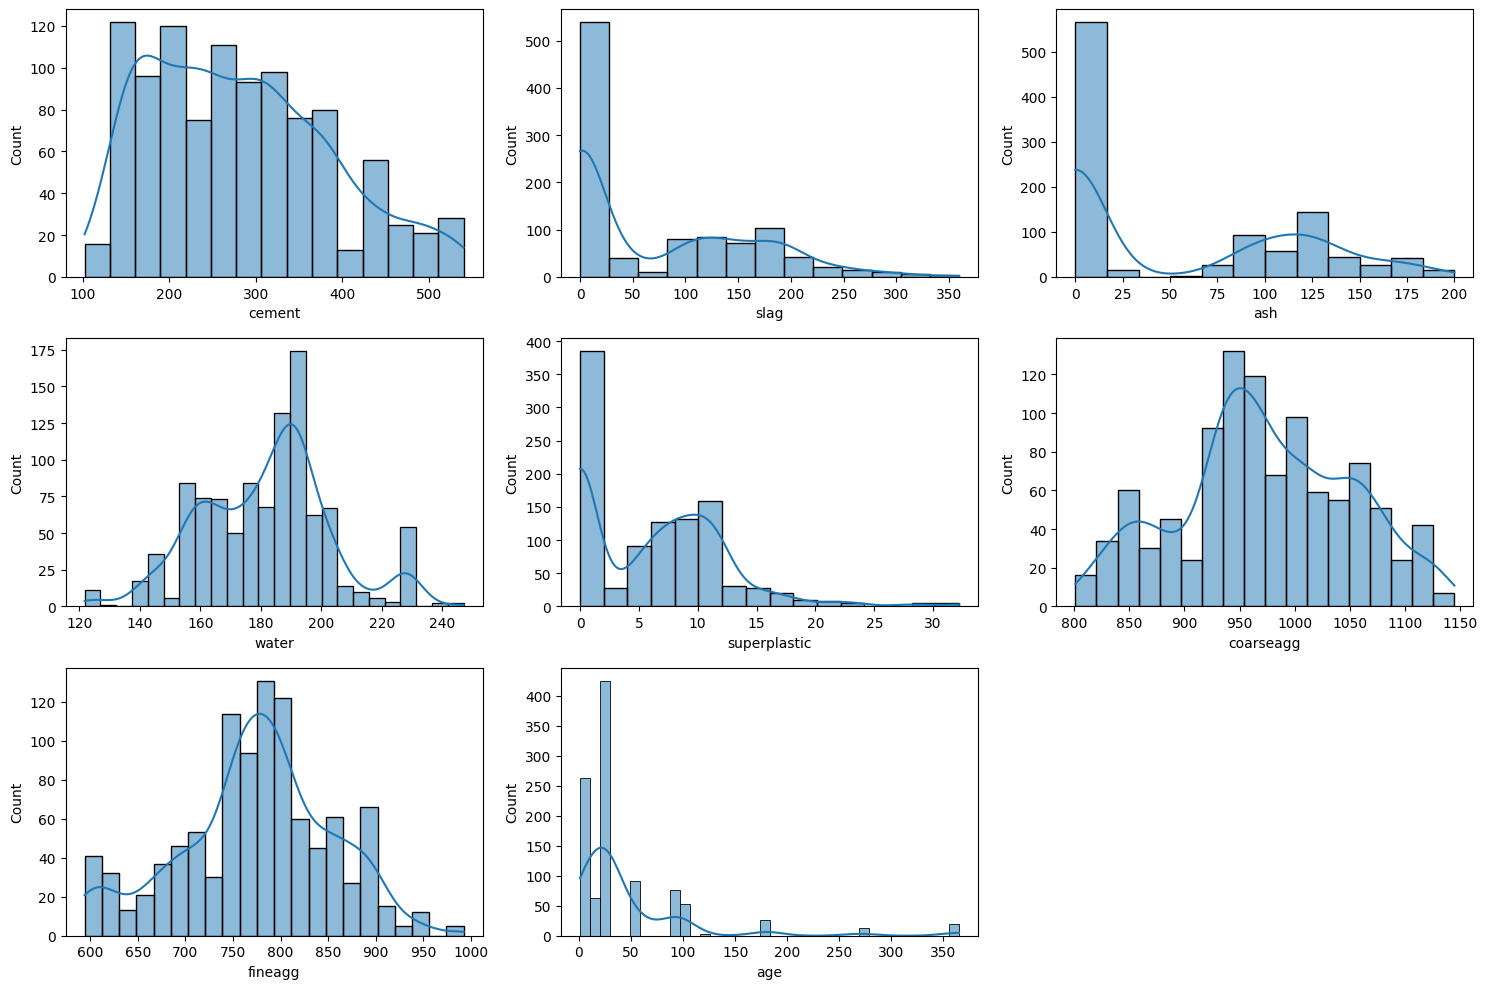

In [249]:
plt.figure(figsize=(15,10))
pos=1
for i in df.columns[:-1]:
    plt.subplot(3,3,pos)
    sns.histplot(x=df[i],kde=True)
    pos+=1
plt.tight_layout()
plt.show()

### 4.2 Multivariate Analysis — Correlation Heatmap

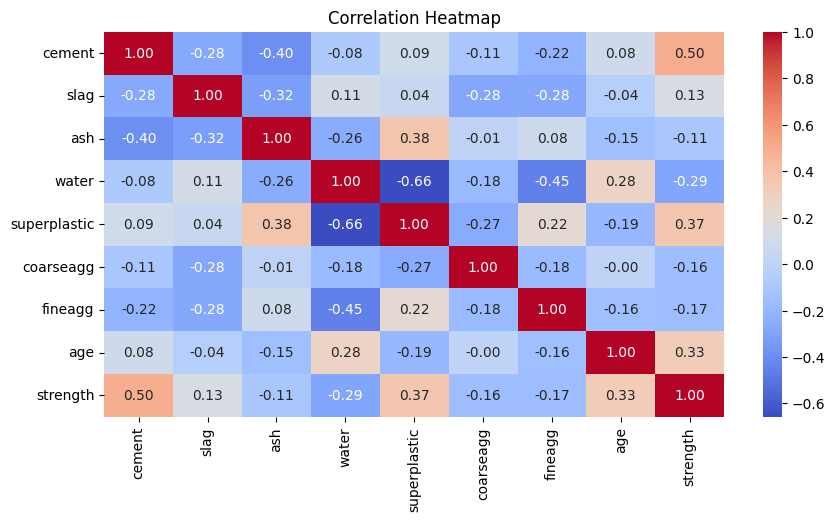

In [250]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 4.3 Bivariate Analysis — Top Features vs Strength

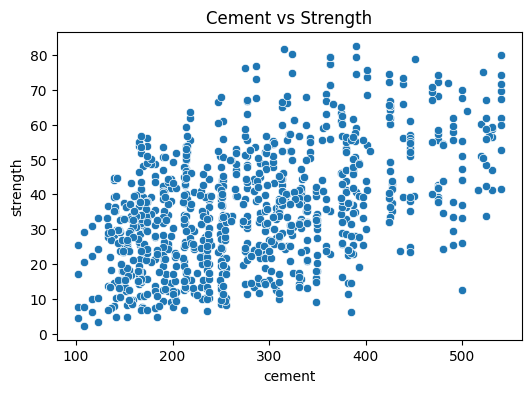

In [251]:
# cement vs strength — scatter
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['cement'], y=df['strength'])
plt.title('Cement vs Strength')
plt.show()

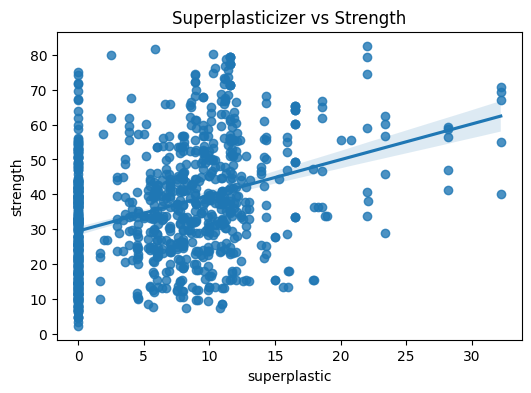

In [252]:
# superplastic vs strength — regplot
plt.figure(figsize=(6,4))
sns.regplot(x=df['superplastic'], y=df['strength'])
plt.title('Superplasticizer vs Strength')
plt.show()

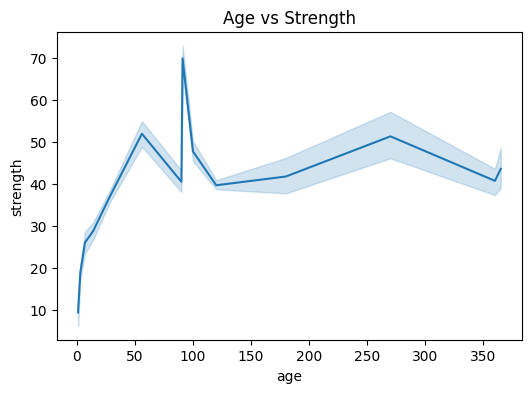

In [253]:
# age vs strength — lineplot
plt.figure(figsize=(6,4))
sns.lineplot(x=df['age'], y=df['strength'])
plt.title('Age vs Strength')
plt.show()

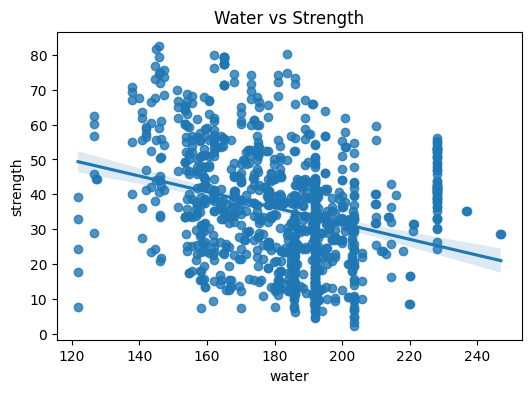

In [254]:
# water vs strength — regplot
plt.figure(figsize=(6,4))
sns.regplot(x=df['water'], y=df['strength'])
plt.title('Water vs Strength')
plt.show()

### 4.4 EDA Insights

**Univariate Insights**
- Cement ranges from 102 to 540 kg/m3 — wide range of mix designs
- Age is heavily right skewed — most samples tested at early ages
- Strength ranges from 2.33 to 82.6 MPa — wide variation confirms nonlinear nature of concrete strength

**Bivariate Insights**
- Cement vs Strength (r=0.50): Strong positive relationship — higher cement content produces stronger concrete
- Age vs Strength (r=0.33): Older concrete is stronger due to hydration process
- Superplasticizer vs Strength (r=0.37): Positive relationship — superplasticizer improves workability without adding water
- Water vs Strength (r=-0.29): Negative relationship confirmed — excess water weakens concrete by increasing porosity

**Correlation Insights**
- Strongest predictor: Cement (0.50)
- Strongest negative predictor: Water (-0.29)
- Water and superplasticizer show -0.66 correlation — superplasticizer reduces water demand, expected relationship
- Coarse and fine aggregate show weak correlation with strength — aggregate quantity matters less than binder quality

**Key Takeaway**  
Concrete strength is driven primarily by cement content, age, and water-cement balance. This is consistent with established civil engineering principles — more binder, less water, more curing time = stronger concrete.

## 5. Data Preprocessing

### 5.1 Missing Values & Duplicates

In [255]:
df.isnull().sum()

,0
cement,0
slag,0
ash,0
water,0
superplastic,0
coarseagg,0
fineagg,0
age,0
strength,0


In [256]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 25


In [257]:
df = df.drop_duplicates()

In [258]:
df = df.copy()
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (1005, 9)


**Data Cleaning**
- Found 25 duplicate rows in the dataset
- Removed using drop_duplicates()
- Remaining records: 1005

### 5.2 Outlier Detection

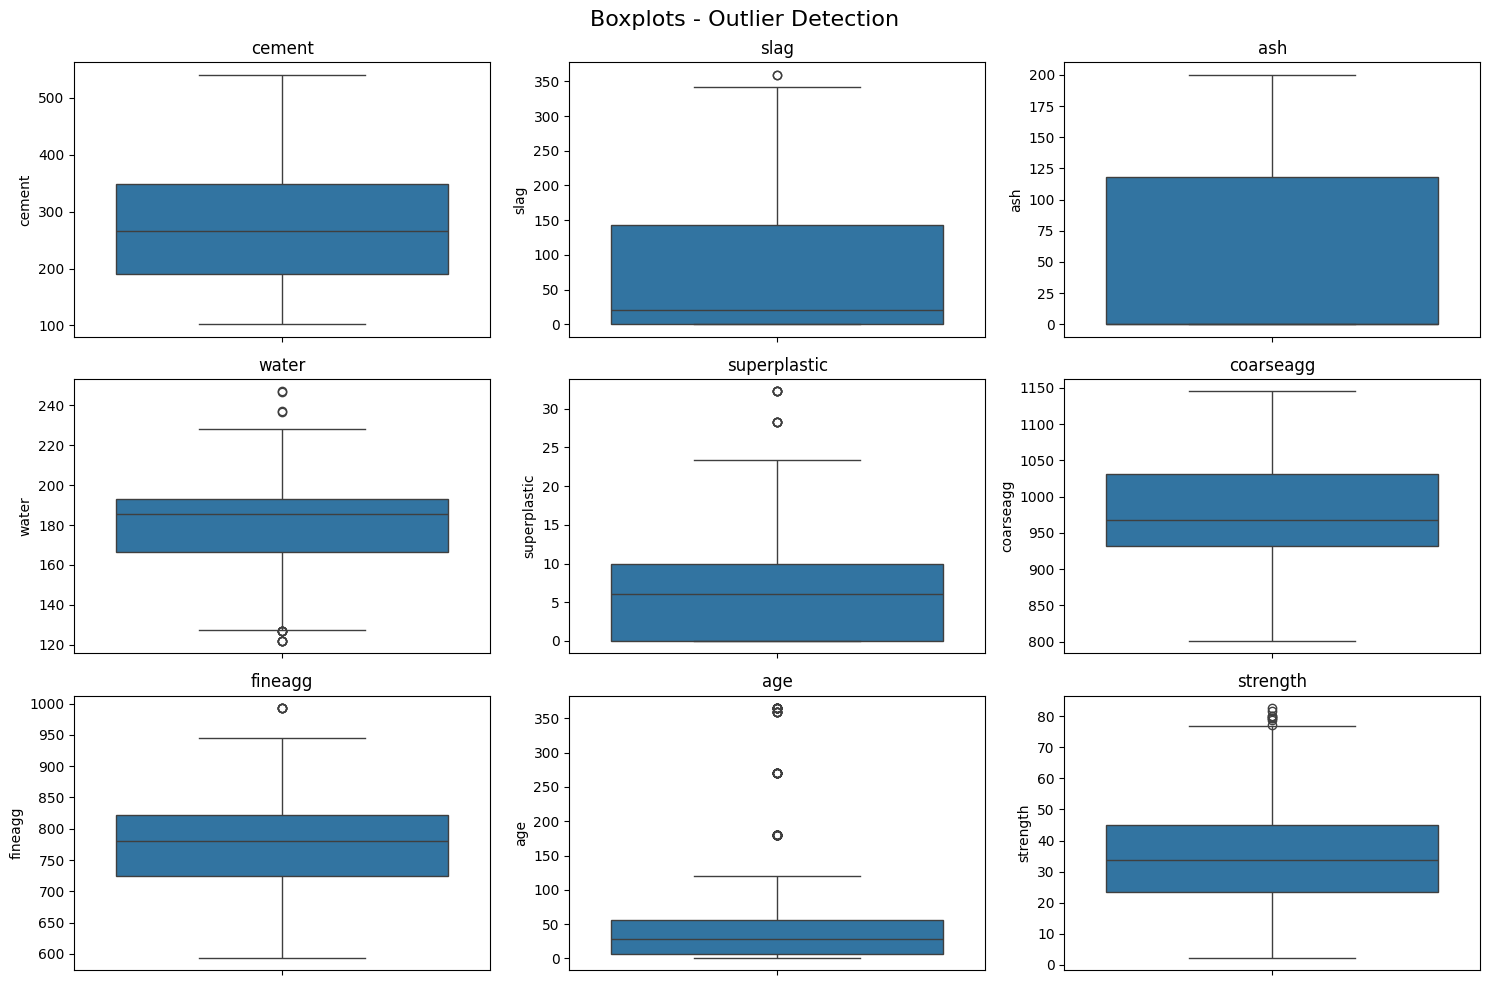

In [259]:
plt.figure(figsize=(15,10))
pos=1
for i in df.columns:
    plt.subplot(3,3,pos)
    sns.boxplot(y=df[i])
    plt.title(i)
    pos+=1
plt.suptitle('Boxplots - Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

In [260]:
print("Skewness  outlier treatment:")
df.skew()

Skewness  outlier treatment:


,0
cement,0.564959
slag,0.855225
ash,0.497231
water,0.034433
superplastic,0.980604
coarseagg,-0.065256
fineagg,-0.252353
age,3.253974
strength,0.395696


In [261]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

cement: 0 outliers
slag: 2 outliers
ash: 0 outliers
water: 15 outliers
superplastic: 10 outliers
coarseagg: 0 outliers
fineagg: 5 outliers
age: 59 outliers
strength: 8 outliers


In [262]:
# Cap water outliers
Q1 = df['water'].quantile(0.25)
Q3 = df['water'].quantile(0.75)
IQR = Q3 - Q1
df['water'] = df['water'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Cap superplastic outliers
Q1 = df['superplastic'].quantile(0.25)
Q3 = df['superplastic'].quantile(0.75)
IQR = Q3 - Q1
df['superplastic'] = df['superplastic'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("Outlier capping done")

Outlier capping done


### 5.3 Skewness Treatment

In [263]:
## Apply log1p to age — skewness was 3.25
df['age'] = np.log1p(df['age'])

print("Skewness after log transform:")
print(df['age'].skew())

Skewness after log transform:
0.005713354025835515


In [264]:
print("Skewness after outlier treatment:")
df.skew()

Skewness after outlier treatment:


,0
cement,0.564959
slag,0.855225
ash,0.497231
water,0.028784
superplastic,0.708386
coarseagg,-0.065256
fineagg,-0.252353
age,0.005713
strength,0.395696


### 5.4 Feature Engineering

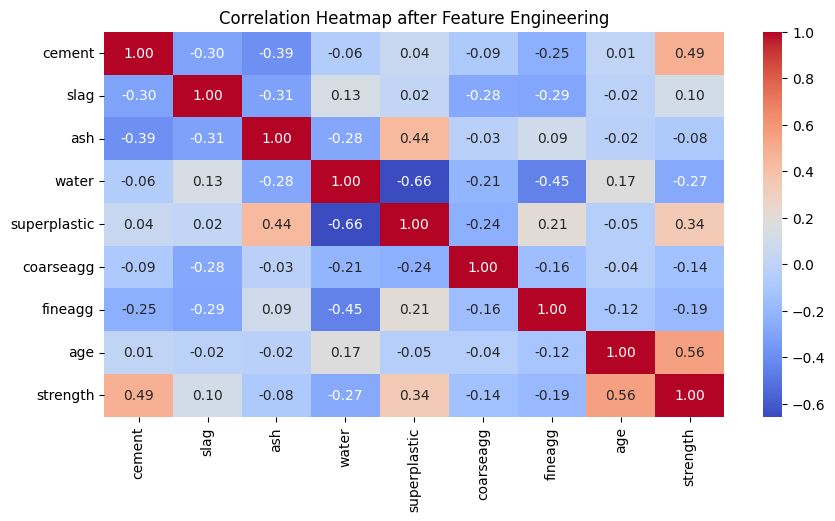

In [265]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap after Feature Engineering')
plt.show()

## Feature Engineering

Water-cement ratio is the most critical engineering factor in concrete
science — lower ratio produces denser, stronger concrete. This is a
well-established civil engineering principle.

Three domain-driven features were engineered:
- water_cement_ratio: Core determinant of concrete durability
- total_binder: Combined cementitious content affecting strength gain
- aggregate_ratio: Balance between aggregates and binder

After correlation analysis, engineered features showed multicollinearity
above 0.9 threshold — reverted to original 8 features for model stability.

## 6. Train Test Split

In [266]:
X=df.drop('strength',axis=1)
y=df['strength']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1005, 8)
y shape: (1005,)


In [267]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (804, 8)
X_test: (201, 8)
y_train: (804,)
y_test: (201,)


## 7. Feature Scaling

In [268]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("Scaling done")

Scaling done


## 8. Model Building & Comparison

### 8.1 Linear Regression

In [269]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
lr_ypred=lr_model.predict(X_test)

In [270]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
lr_r2=r2_score(y_test,lr_ypred)
lr_mae=mean_absolute_error(y_test,lr_ypred)
lr_mse=mean_squared_error(y_test,lr_ypred)
lr_rmse=rmse = np.sqrt(mean_squared_error(y_test, lr_ypred))

In [271]:
print('R2 score:',lr_r2)
print('MAE:',lr_mae)
print('MSE:',lr_mse)
print('RMSE:',lr_rmse)

R2 score: 0.8016147678414367
MAE: 5.856345894173528
MSE: 59.18325248821193
RMSE: 7.69306522058743


### 8.2 Decision Tree

In [272]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor()
dt_model.fit(X_train,y_train)
dt_ypred=dt_model.predict(X_test)

In [273]:
dt_r2=r2_score(y_test,dt_ypred)
dt_mae=mean_absolute_error(y_test,dt_ypred)
dt_mse=mean_squared_error(y_test,dt_ypred)
dt_rmse=np.sqrt(mean_squared_error(y_test, dt_ypred))

In [274]:
print('R2 score:',dt_r2)
print('MAE:',dt_mae)
print('MSE:',dt_mse)
print('RMSE:',dt_rmse)

R2 score: 0.8842316083503505
MAE: 3.729875621890547
MSE: 34.53659266169154
RMSE: 5.876784210917697


### 8.3 Random Forest

In [275]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(X_train,y_train)
rf_ypred=rf_model.predict(X_test)

In [276]:
rf_r2=r2_score(y_test,rf_ypred)
rf_mae=mean_absolute_error(y_test,rf_ypred)
rf_mse=mean_squared_error(y_test,rf_ypred)
rf_rmse=np.sqrt(mean_squared_error(y_test, rf_ypred))

In [277]:
print('R2 score:',rf_r2)
print('MAE:',rf_mae)
print('MSE:',rf_mse)
print('RMSE:',rf_rmse)

R2 score: 0.9088877979396071
MAE: 3.4909805093579735
MSE: 27.181037623744604
RMSE: 5.2135436723733894


### 8.4 XGBoost

In [278]:
from xgboost import XGBRegressor
xg_model=XGBRegressor()
xg_model.fit(X_train,y_train)
xg_ypred=xg_model.predict(X_test)

In [279]:
xg_r2=r2_score(y_test,xg_ypred)
xg_mae=mean_absolute_error(y_test,xg_ypred)
xg_mse=mean_squared_error(y_test,xg_ypred)
xg_rmse=np.sqrt(mean_squared_error(y_test, xg_ypred))

In [280]:
print('R2 score:',xg_r2)
print('MAE:',xg_mae)
print('MSE:',xg_mse)
print('RMSE:',xg_rmse)

R2 score: 0.9321616804260654
MAE: 2.8195174656578557
MSE: 20.23785919967673
RMSE: 4.498650819932208


### 8.5 Model Comparison Report

In [281]:
comparison_df = pd.DataFrame({
    'Model':  ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'R2':     [round(lr_r2,4), round(dt_r2,4), round(rf_r2,4), round(xg_r2,4)],
    'MAE':    [round(lr_mae,3), round(dt_mae,3), round(rf_mae,3), round(xg_mae,3)],
    'MSE':    [round(lr_mse,3), round(dt_mse,3), round(rf_mse,3), round(xg_mse,3)],
    'RMSE':   [round(lr_rmse,3), round(dt_rmse,3), round(rf_rmse,3), round(xg_rmse,3)]
})

print(comparison_df.sort_values('R2', ascending=False).to_string(index=False))

            Model     R2   MAE    MSE  RMSE
          XGBoost 0.9322 2.820 20.238 4.499
    Random Forest 0.9089 3.491 27.181 5.214
    Decision Tree 0.8842 3.730 34.537 5.877
Linear Regression 0.8016 5.856 59.183 7.693


**Model Comparison Insights**

1. Linear Regression scored lowest R2 (0.80) — confirms concrete strength has nonlinear relationships with ingredients
2. Decision Tree improved significantly (0.88) but tends to overfit
3. Random Forest further improved (0.91) due to ensemble averaging
4. XGBoost performed best (R2=0.93, RMSE=4.49) — selected for production

**Conclusion:** Nonlinear ensemble models outperform linear models on this dataset as expected from correlation analysis.

## 9. Hyperparameter Tuning — XGBoost (Best Model)

In [282]:
from xgboost import XGBRegressor
xgb_clf=XGBRegressor()

params={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.03,0.05,0.07,0.1],
    'max_depth':[2,3,4,5,6,7],
    'gamma':[0,0.1]
    }

from sklearn.model_selection import GridSearchCV
xgb_cv=GridSearchCV(
    xgb_clf,
    params,
    scoring='r2',
    n_jobs=-1,
    verbose=5,
    cv=5
    )

xgb_cv.fit(X_train,y_train)
best_params=xgb_cv.best_params_

print(best_params)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}


In [283]:
#{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}-- 93.25 r2

tuned_xg=XGBRegressor(**best_params,random_state=42)
tuned_xg.fit(X_train,y_train)
tuned_xg_ypred=tuned_xg.predict(X_test)

In [284]:
tuned_xg_r2=r2_score(y_test,tuned_xg_ypred)
tuned_xg_mae=mean_absolute_error(y_test,tuned_xg_ypred)
tuned_xg_mse=mean_squared_error(y_test,tuned_xg_ypred)
tuned_xg_rmse=np.sqrt(mean_squared_error(y_test, tuned_xg_ypred))

In [285]:
print('R2 score:',tuned_xg_r2)
print('MAE:',tuned_xg_mae)
print('MSE:',tuned_xg_mse)
print('RMSE:',tuned_xg_rmse)

R2 score: 0.9325558955636003
MAE: 2.919480437236046
MSE: 20.12025501228057
RMSE: 4.48556072440008


**Hyperparameter Tuning Results**

Used GridSearchCV with 5-fold cross validation — 180 combinations tested.  
Best parameters: gamma=0, learning_rate=0.1, max_depth=4, n_estimators=300

Improvement after tuning was marginal (R2: 0.9322 → 0.9326).  
This indicates default XGBoost parameters were already near-optimal for this dataset size of 1005 rows.

## 10. Model Evaluation — Best Model

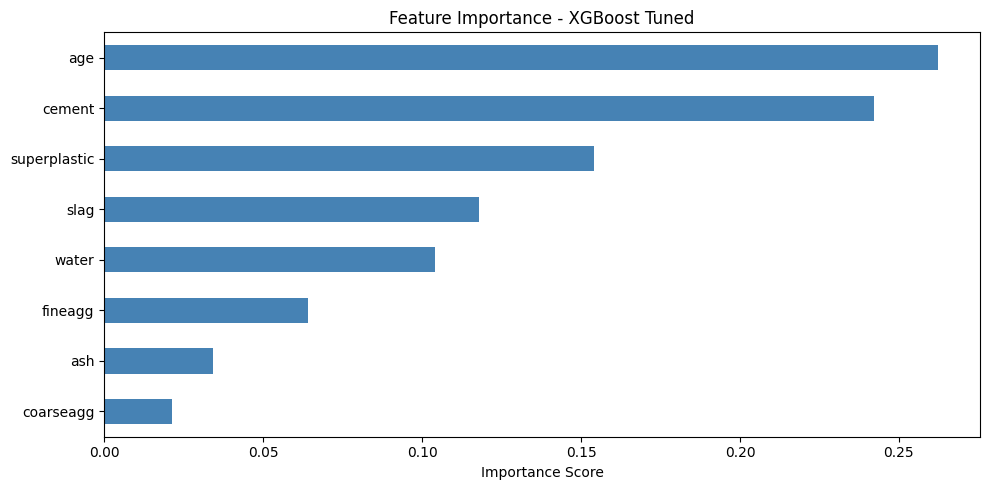

In [286]:
# Feature Importance
plt.figure(figsize=(10,5))
feat_imp = pd.Series(tuned_xg.feature_importances_,
                     index=X.columns).sort_values()
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - XGBoost Tuned')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

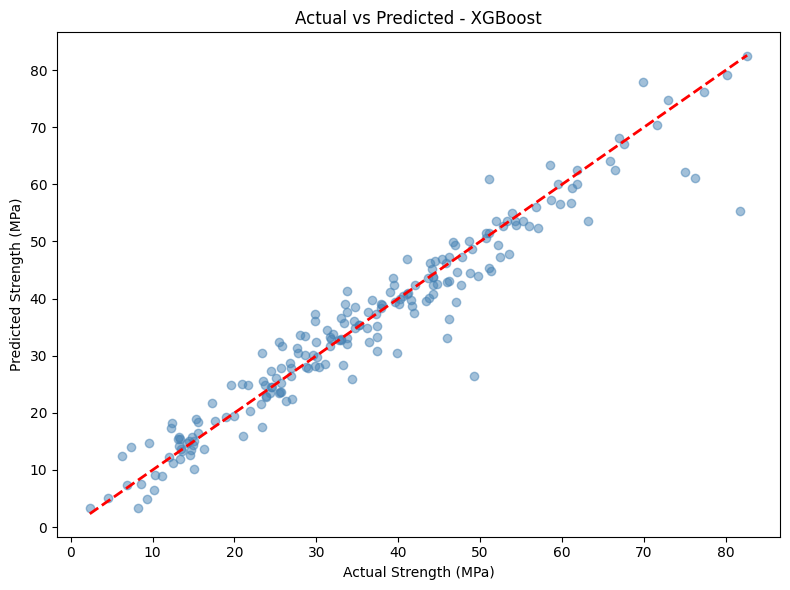

In [287]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, tuned_xg_ypred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)') #Megapascal, Concrete strength unit.
plt.title('Actual vs Predicted - XGBoost')
plt.tight_layout()
plt.show()

## Model Diagnostics

### SHAP Analysis
SHAP (SHapley Additive exPlanations) explains individual
predictions by showing each feature's contribution to the output.

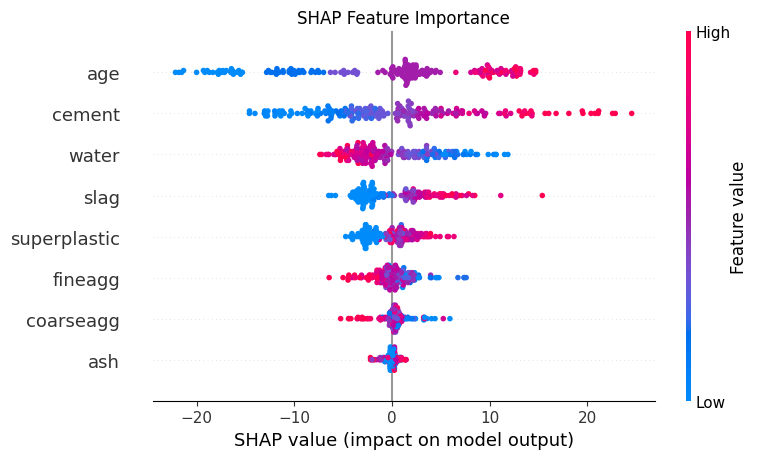

In [288]:
import shap

explainer = shap.TreeExplainer(tuned_xg)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

### Residual Analysis
Residuals = Actual - Predicted
- Good model: residuals randomly scattered around zero
- Pattern in residuals = model is missing something
- Normal distribution of residuals = model assumptions satisfied

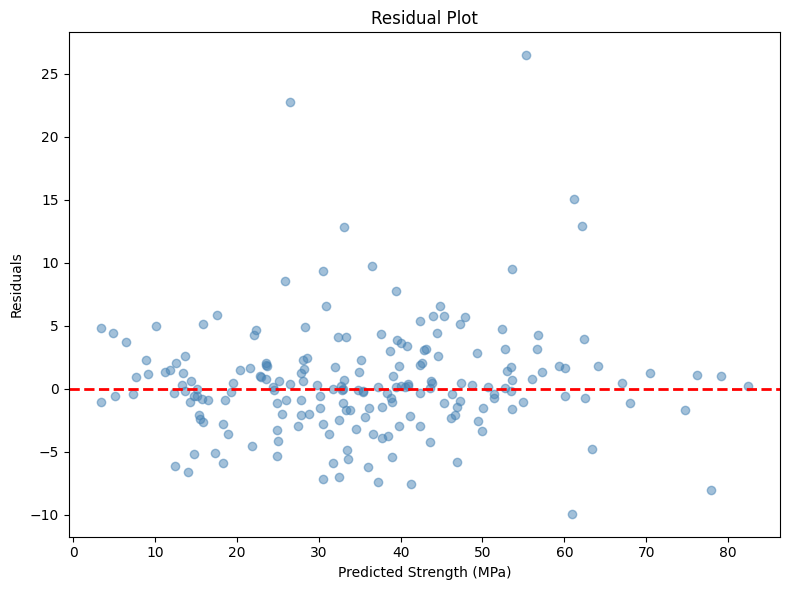

In [289]:
residuals = y_test - tuned_xg_ypred

plt.figure(figsize=(8,6))
plt.scatter(tuned_xg_ypred, residuals, alpha=0.5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Strength (MPa)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

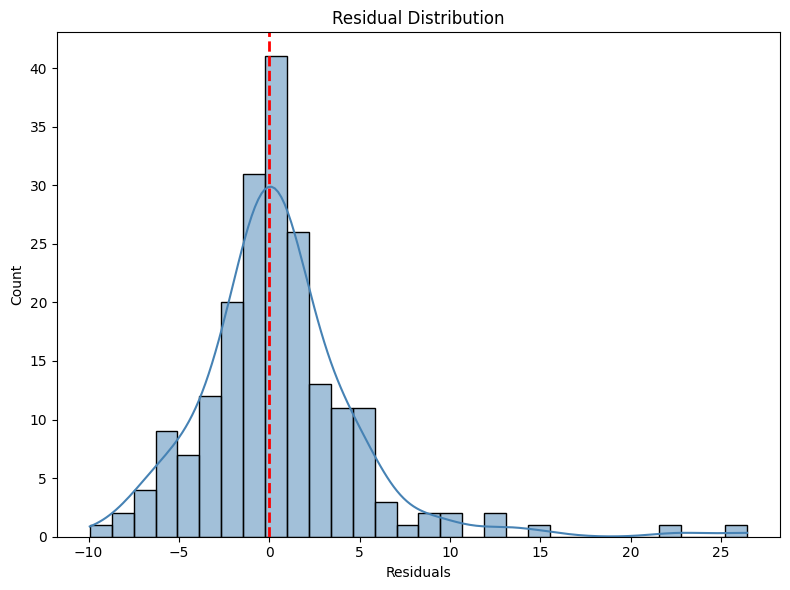

In [290]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

## 11. Save Model & Scaler

In [291]:
import pickle

# Save model
with open('concrete_model.pkl', 'wb') as f:
    pickle.dump(tuned_xg, f)

# Save scaler
with open('concrete_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved:", 'concrete_model.pkl')
print("Scaler saved:", 'concrete_scaler.pkl')

Model saved: concrete_model.pkl
Scaler saved: concrete_scaler.pkl


In [292]:
from google.colab import files
files.download('concrete_model.pkl')
files.download('concrete_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Challenges Faced & Solutions

### Challenge 1 — Duplicate Rows
- **Problem:** Found 25 duplicate rows in the dataset
- **Technique:** Removed using drop_duplicates()
- **Reason:** Duplicate rows cause model to overfit on repeated data

### Challenge 2 — SettingWithCopyWarning
- **Problem:** Pandas warning after drop_duplicates() operation
- **Technique:** Used df.copy() to create explicit independent dataframe
- **Reason:** Ensures changes are made on original dataframe not a slice

### Challenge 3 — Outliers in Water and Superplasticizer
- **Problem:** 15 outliers in water, 10 outliers in superplasticizer
- **Technique:** Capped using IQR method
- **Reason:** Dataset only has 1005 rows — removing rows risks losing data. Capping preserves rows while reducing extreme value effect

### Challenge 4 — Age Outliers Flagged by IQR
- **Problem:** IQR method flagged 59 outliers in age column
- **Technique:** Left untreated
- **Reason:** Concrete is tested from day 1 to 365 in labs. These are genuine measurements not errors

### Challenge 5 — High Skewness in Age Column
- **Problem:** Age had skewness of 3.25 — highly right skewed
- **Technique:** Applied log1p transformation
- **Reason:** log1p handles zero values safely. Reduced skewness from 3.25 to 0.006

### Challenge 6 — Multicollinearity in Engineered Features
- **Problem:** water_cement_ratio had -0.91 correlation with cement. aggregate_ratio had -0.95 correlation with total_binder
- **Technique:** Reverted to original 8 features
- **Reason:** Multicollinearity above 0.9 makes model unstable and reduces interpretability

### Challenge 7 — Nonlinear Relationships
- **Problem:** Linear regression gave low R2 of 0.80
- **Technique:** Used tree based models — Random Forest and XGBoost
- **Reason:** Concrete strength is a nonlinear function of ingredients as stated in the problem statement itself

### Challenge 8 — Hyperparameter Tuning
- **Problem:** Default XGBoost needed optimization
- **Technique:** Used GridSearchCV with 5-fold cross validation
- **Reason:** Systematic search across parameter combinations gives best model configuration. Best params: learning_rate=0.1, max_depth=4, n_estimators=300

## 13. Conclusion & Business Impact

| Metric | Value |
|--------|-------|
| Best Model | XGBoost (Hypertuned) |
| R2 Score | 0.9326 |
| RMSE | 4.486 MPa |
| MAE | 2.919 MPa |

**Business Impact:**
This model can be integrated into construction quality management systems
to assist engineers in estimating concrete performance before 28-day
physical testing — potentially reducing testing costs by 60-70% and
improving material planning efficiency.

**Key Finding:**
Age is the most important predictor — confirming that concrete gains
strength through hydration over time. This aligns with civil engineering
domain knowledge and validates model reliability.

**Production Recommendation:**
Deploy XGBoost with parameters gamma=0, learning_rate=0.1,
max_depth=4, n_estimators=300 for real-time strength estimation
in construction quality workflows.